# Segmented Regression (SLR):

This is continuation of the notebook **01. Exploratory Data Analysis**, In an attempt to replicate [1], we implement methods in the paper in Python. For Segmented Regression , 

we use `pwlf` python package. (`pip install pwlf`)

"A library for fitting continuous piecewise linear functions to data. Just specify the number of line segments you desire and provide the data." - [pwlf](https://pypi.org/project/pwlf/)

[1] Zavorsky, Gerald (2024), “Refined NHANES 2007-2012 spirometry dataset for the comparison of segmented (piecewise) linear models to that of GAMLSS”, Mendeley Data, V1, doi: 10.17632/dwjykg3xww.1

In [1]:
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import pandas as pd
import sys
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm

current_dir = Path.cwd()
script_dir = f'{current_dir.parent}/scripts'
sys.path.append(script_dir) 
from lib import load_preprocessed_df, select_optimal_segments, create_segmented_basis_features
from lib import visualize_and_interpret_model, perform_model_diagnostics, lasso_feature_selection

import pwlf

In [2]:
df = load_preprocessed_df()

In [3]:
df.shape

(16596, 18)

In [4]:
df.columns

Index(['Age', 'LnAge', 'Age2', 'Age3', 'Age_Groups', 'Sex', 'Race', 'Height',
       'LnHeight', 'Height2', 'Weight', 'BMI', 'Height2_x_Race', 'Age_Height',
       'Age_Height2', 'Baseline_FEV1_L', 'Baseline_FVC_L',
       'Baseline_FEV1_FVC_Ratio'],
      dtype='object')

In [5]:
# Essential columns for initial SLR model (selected based on the paper [1])
slr_columns = [
    'Age',
    'Age2',
    'Height',
    'Sex',
    'Race',
    'Baseline_FEV1_L',
    'Baseline_FVC_L',
    'Baseline_FEV1_FVC_Ratio'
]

df_slr = df[slr_columns].copy()

##### Encode categorical variables

In [6]:
le = LabelEncoder()
# Sex
df_slr['Sex'] = le.fit_transform(df_slr['Sex'])
# race
race_dummies = pd.get_dummies(df_slr['Race'], prefix='Race', dtype=int)
df_slr = pd.concat([df_slr, race_dummies], axis=1) 
df_slr = df_slr.drop('Race', axis=1)

In [7]:
df_slr.head()

,Age,Age2,Height,Sex,Baseline_FEV1_L,Baseline_FVC_L,Baseline_FEV1_FVC_Ratio,Race_Black,Race_Mexican American,Race_Other hispanic,Race_Other_or_multi-racial,Race_White
0,62.50,3906.2500,154.7,0,2.025,2.473,0.818844,0,0,0,1,0
1,6.75,45.5625,120.4,0,1.551,1.742,0.890356,0,0,0,1,0
2,52.50,2756.2500,154.4,1,2.957,3.545,0.834133,0,1,0,0,0
3,21.25,451.5625,182.7,1,4.541,4.928,0.921469,1,0,0,0,0
4,64.75,4192.5625,173.8,1,2.920,3.907,0.747377,0,1,0,0,0


In [8]:
df_slr.head()

,Age,Age2,Height,Sex,Baseline_FEV1_L,Baseline_FVC_L,Baseline_FEV1_FVC_Ratio,Race_Black,Race_Mexican American,Race_Other hispanic,Race_Other_or_multi-racial,Race_White
0,62.50,3906.2500,154.7,0,2.025,2.473,0.818844,0,0,0,1,0
1,6.75,45.5625,120.4,0,1.551,1.742,0.890356,0,0,0,1,0
2,52.50,2756.2500,154.4,1,2.957,3.545,0.834133,0,1,0,0,0
3,21.25,451.5625,182.7,1,4.541,4.928,0.921469,1,0,0,0,0
4,64.75,4192.5625,173.8,1,2.920,3.907,0.747377,0,1,0,0,0


## Create SLR models  for each target Variable

###### Reproducing Instruction in [Dataset Website at Mendely](https://data.mendeley.com/datasets/dwjykg3xww/1)

- Included the squared age term to facilitate estimation of breakpoints across the 5–80 year age range.

- Breakpoints and their 95% confidence intervals were identified using a combination of visual inspection and iterative methods.

- LASSO regression was applied to select important predictors, including age, height, weight, interaction terms, and squared terms, guided by the **Bayesian Information Criterion (BIC)**.

- Models were assessed for multicollinearity, outliers, and adherence to underlying assumptions.

##### Step 1: Use Age2 as the Breakpoint Variable with Polynomial Terms

#### Baseline_FEV1_L

In [9]:
TARGET = 'Baseline_FEV1_L' 

--- Testing Models from 1 to 6 Segments ---
Segments: 1 | BIC: -1690.6149
Segments: 2 | BIC: -12480.4549
Segments: 3 | BIC: -12539.6386
Segments: 4 | BIC: -12565.1268
Segments: 5 | BIC: -12574.1384
Segments: 6 | BIC: -12559.7394

 optimal segments (min BIC):: 5


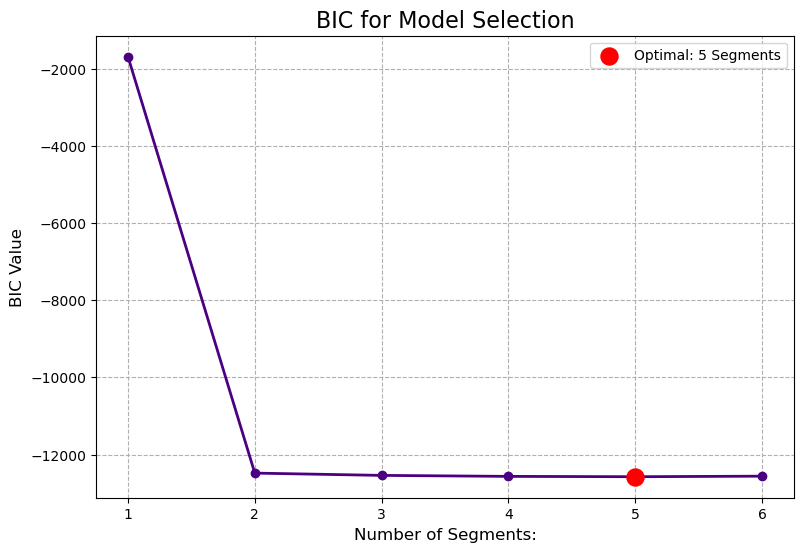

In [10]:
# BIC selection
best_k = select_optimal_segments(
    df=df_slr,
    x_col='Age',
    y_col=TARGET,
    max_segments=6
)

In [11]:
X = df_slr['Age'].values
Y = df_slr[TARGET].values
final_pwlf = pwlf.PiecewiseLinFit(X, Y)
final_breakpoints = final_pwlf.fit(best_k)
 
print(f"Fit with {best_k} segments:")
print(f"Breakpoints (based on Age):") 
actual_knots = final_breakpoints[1:-1] 
print(actual_knots)

Fit with 5 segments:
Breakpoints (based on Age):
[10.24993103 15.21001185 18.59963996 32.25000267]


Model: (5 Segments)
R-squared: 0.4862
Breakpoints (Ages): [10.25 15.2  18.55 31.25]


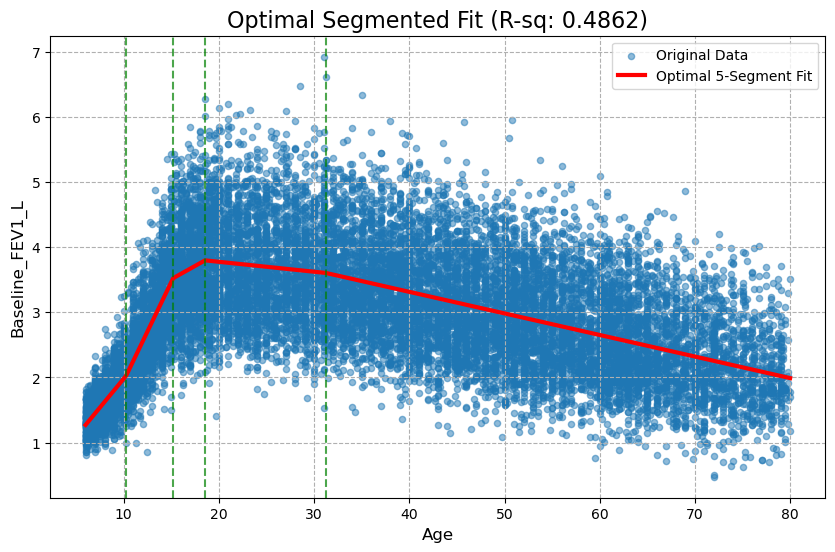

In [12]:
FINAL_KNOTS = visualize_and_interpret_model(df_slr, 'Age', TARGET, best_k)

#### Step 2: Multiple Segmented Regression

In [13]:
selected_non_age_features = lasso_feature_selection(df_slr, TARGET)
segmented_df = create_segmented_basis_features(df_slr, FINAL_KNOTS, age_col='Age')

segmented_age_features = [col for col in segmented_df.columns if col.startswith('Age_Knot_')]
# all features
final_predictors = ['Age'] + selected_non_age_features + segmented_age_features

X = segmented_df[final_predictors]
Y = segmented_df[TARGET]

# 2. Add Constant for the Intercept
X = sm.add_constant(X)

# 3. Fit the OLS model
model = sm.OLS(Y, X).fit() 
print(f"Total Observations: {len(df)}")
print(f"R-squared: {model.rsquared:.4f} (Improved from FEV1 vs Age only!)")
print("\n--- Model Coefficients (Slopes/Effects) ---")
print(model.summary().tables[1]) 

Selected features(except age): ['Height', 'Baseline_FVC_L', 'Baseline_FEV1_FVC_Ratio']
Created 4 segmented basis features for Age.
Total Observations: 16596
R-squared: 0.9914 (Improved from FEV1 vs Age only!)

--- Model Coefficients (Slopes/Effects) ---
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      -3.2204      0.017   -185.291      0.000      -3.254      -3.186
Age                         0.0161      0.001     11.396      0.000       0.013       0.019
Height                      0.0013      0.000     11.814      0.000       0.001       0.001
Baseline_FVC_L              0.7717      0.001    665.439      0.000       0.769       0.774
Baseline_FEV1_FVC_Ratio     3.5832      0.010    347.366      0.000       3.563       3.603
Age_Knot_1_10               0.0056      0.002      2.749      0.006       0.002       0.010
Age_Knot_2


--- Model Validation and Diagnostics ---

[1] Multicollinearity (VIF Score) Check:
Rule of Thumb: VIF > 5 or 10 suggests problematic multicollinearity.
                   Feature          VIF
0            Age_Knot_2_15  6797.580677
1            Age_Knot_1_10  6699.382363
2                      Age  5926.045968
3            Age_Knot_3_18  3032.697826
4                   Height   490.378101
5  Baseline_FEV1_FVC_Ratio   103.042822
6            Age_Knot_4_31    59.164650
7           Baseline_FVC_L    39.094140


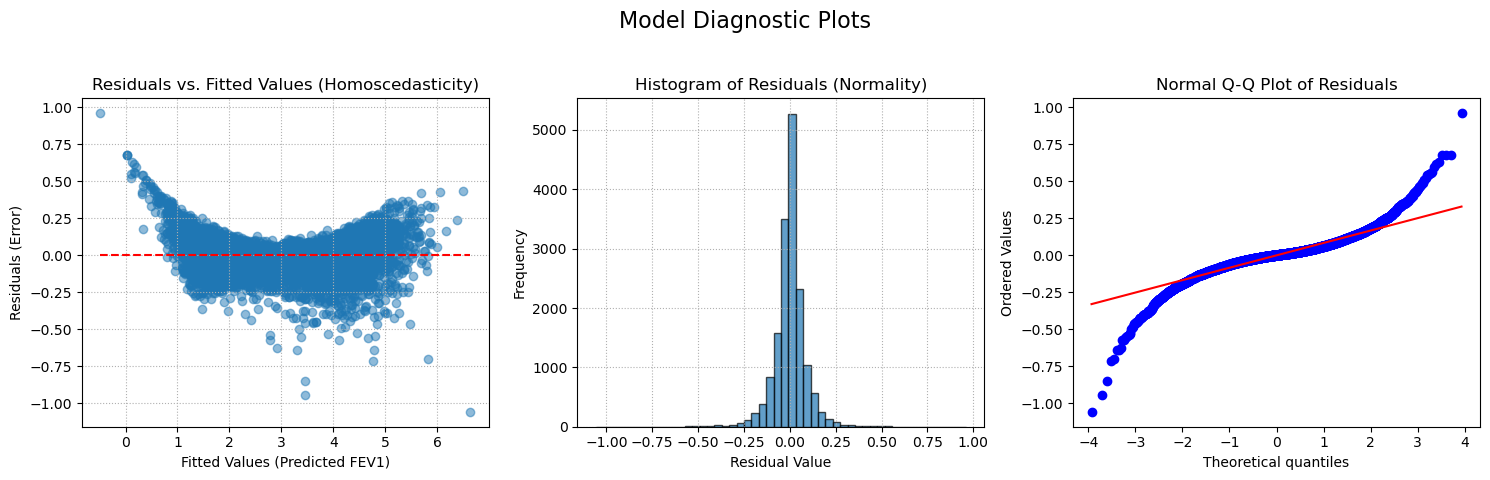

In [14]:
perform_model_diagnostics(model, segmented_df, final_predictors)

Model Validation Summary
- Excellent Normality: The residuals (errors) show a strong, symmetrical, bell-shaped distribution and closely follow the red line on the Q-Q Plot, confirming the normality assumption of the model.
- High Predictive Power Confirmed: The model is an extremely accurate fit for the central range of FEV1 values (Predicted FEV1 $\approx 2.0$ to $5.0$ L).
- Heteroscedasticity Detected: The Residuals vs. Fitted Values plot exhibits a noticeable U-shape. This indicates that the prediction error is not constant, but is larger at the extreme (low and high) FEV1 values.
- No Bias, but Caution is Needed: The heteroscedasticity does not bias the calculated coefficients (slopes), but it means the standard errors and, consequently, the $\boldsymbol{p}$-values are slightly inaccurate.